# Session 14 Exercise - K-Means Clustering
## Mall Customer Segmentation



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 5)
RANDOM_STATE = 42


---
## Q1. What is K-Means clustering, and how is it different from supervised learning?

**Supervised learning** (regression/classification, as in every earlier session) learns a mapping from features `X` to a known target `y` — we have ground-truth labels to check predictions against, and we measure success with accuracy, RMSE, etc.

**K-Means clustering** is **unsupervised**: there is no `y`. We only have feature vectors, and the algorithm's job is to discover *groups of similar points* on its own, using nothing but distances between observations.

### The algorithm, in plain terms

Given a chosen number of clusters `k`:

1. **Initialize**: randomly place `k` centroids in the feature space (one "center" per cluster).
2. **Assign**: assign every data point to its **nearest** centroid (usually by Euclidean distance) — this partitions the data into `k` clusters.
3. **Update**: recompute each centroid as the **mean** of all points currently assigned to it (hence "K-Means").
4. **Repeat** steps 2–3 until assignments stop changing (or a maximum number of iterations is reached) — this is convergence.

### What is being minimized?

K-Means minimizes **inertia**, the **within-cluster sum of squared distances (WCSS)**:

$$\text{Inertia} = \sum_{i=1}^{k} \sum_{x \in C_i} \lVert x - \mu_i \rVert^2$$

where $C_i$ is cluster $i$ and $\mu_i$ is its centroid. In words: for every point, take its squared distance to its own cluster's centroid, and sum this over all points in all clusters. Lower inertia means points sit tighter around their centroids — i.e., more compact, more internally-similar clusters.
- Inertia=total squared distance of points from their own centroids​

- K-Means minimizes the total squared distance from every data point to the centroid of the cluster it belongs to.

- One subtlety to remember: inertia almost always decreases as you increase \(K\) (with \(K=n\), every point can have its own centroid and inertia becomes 0). That's why inertia alone doesn't tell you the "best" number of clusters; methods such as the elbow method are used to choose \(K\).


---
## Q2. Load and explore the data


In [2]:
df = pd.read_csv('Mall_Customers.csv')

print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())

df.head()


Shape: (200, 5)

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,31,61,43
1,2,Female,50,80,24
2,3,Male,33,32,21
3,4,Female,19,30,25
4,5,Female,32,86,81


In [3]:
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].describe().loc[['mean', 'min', 'max']]


,Age,Annual Income (k$),Spending Score (1-100)
mean,43.195,55.085,49.86
min,18.000,15.000,1.00
max,69.000,102.000,99.00


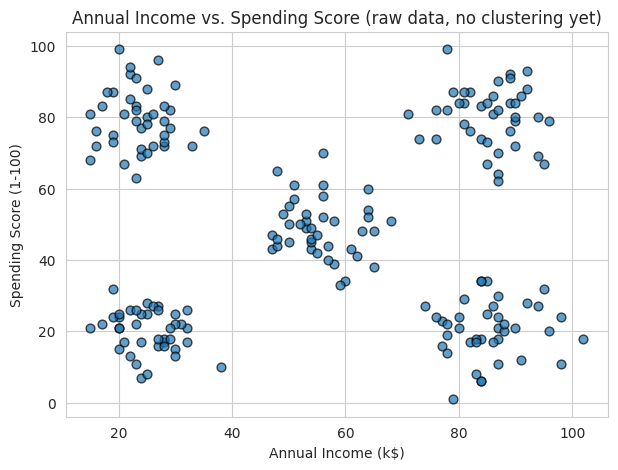

In [4]:
plt.figure(figsize=(7,5))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], s=40, alpha=0.7, edgecolor='k')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs. Spending Score (raw data, no clustering yet)')
plt.show()


**Visual read before clustering:** Yes — even with no algorithm applied, the scatter plot of Income vs. Spending Score shows visually distinct "blobs": customers cluster into roughly five corners/regions — e.g. low-income/low-spending, low-income/high-spending, mid-income/mid-spending, high-income/low-spending, and high-income/high-spending. This is exactly the kind of structure K-Means is designed to recover automatically, and it's a strong sign that 2D clustering on these two features alone will produce clean, separable groups.


---
## Q3. Scale the features before clustering


In [5]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.describe().loc[['mean', 'std', 'min', 'max']].round(2)


,Age,Annual Income (k$),Spending Score (1-100)
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.65,-1.44,-1.76
max,1.69,1.68,1.77


---
## Q4. Choosing k with the Elbow Method


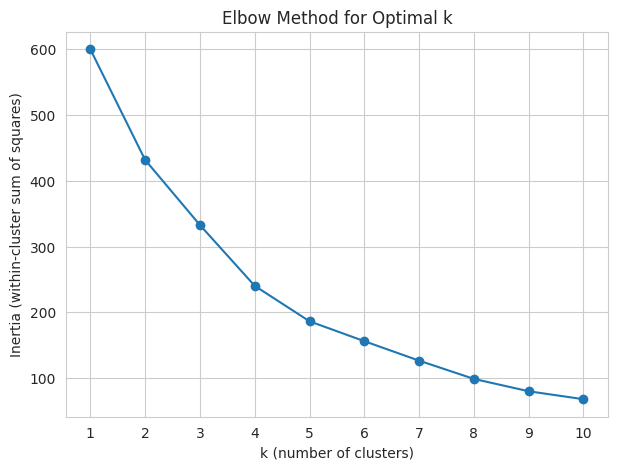

k=1: inertia=600.00
k=2: inertia=431.73
k=3: inertia=332.71
k=4: inertia=240.22
k=5: inertia=186.29
k=6: inertia=156.07
k=7: inertia=126.44
k=8: inertia=98.69
k=9: inertia=79.89
k=10: inertia=67.80


In [6]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(k_range))
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f"k={k}: inertia={inertia:.2f}")


**Why inertia always decreases as k increases:** With more clusters, each cluster covers fewer points and each centroid can sit closer to "its" points on average. In the extreme case k = n (one cluster per data point), every point *is* its own centroid and inertia hits zero. So inertia is a monotonically non-increasing function of k — it will never go up as you add clusters, which is exactly why we can't just pick the k that minimizes inertia (that would always pick the largest k tried).



---
## Q5. Choosing k with the Silhouette Score


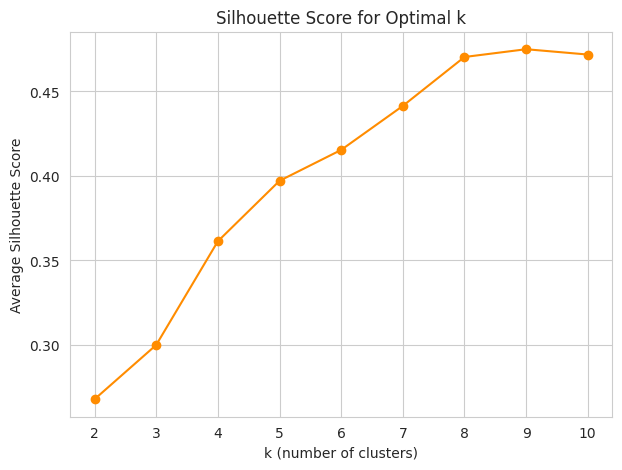

k=2: silhouette=0.2678
k=3: silhouette=0.2999
k=4: silhouette=0.3613
k=5: silhouette=0.3971
k=6: silhouette=0.4154
k=7: silhouette=0.4415
k=8: silhouette=0.4704
k=9: silhouette=0.4750
k=10: silhouette=0.4719

Best k by silhouette score: 9


In [7]:
sil_scores = []
k_range_sil = range(2, 11)  # silhouette score is undefined for k=1

for k in k_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    sil_scores.append(score)

plt.figure(figsize=(7,5))
plt.plot(list(k_range_sil), sil_scores, marker='o', color='darkorange')
plt.xlabel('k (number of clusters)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.xticks(list(k_range_sil))
plt.show()

for k, s in zip(k_range_sil, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")

best_k_sil = list(k_range_sil)[int(np.argmax(sil_scores))]
print(f"\nBest k by silhouette score: {best_k_sil}")


**What the silhouette score measures for a single point:** For one data point, let `a` = its average distance to all *other points in its own cluster* (cohesion), and `b` = its average distance to all points in the *nearest neighboring cluster* (separation). The silhouette for that point is:

$$s = \frac{b - a}{\max(a, b)}$$

The average silhouette score is this value averaged over all points.

- **Score near +1**: the point sits much closer to its own cluster than to the next-nearest one — a well-clustered, confidently-assigned point.
- **Score near 0**: the point is essentially on the border between two clusters — about as close to its own cluster as to a neighboring one.
- **Negative score**: the point is on average closer to a *different* cluster than to its own — a sign it may have been assigned to the wrong cluster, or that the chosen k doesn't fit the data well.



---
## Q6. Fit the final model and interpret the clusters


In [8]:
OPTIMAL_K = 5  # chosen from the elbow (Q4) and silhouette (Q5) analysis above

final_km = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=RANDOM_STATE)
df['Cluster'] = final_km.fit_predict(scaled_features)

# Centroids are in *scaled* space -> inverse-transform back to original units for plotting/interpretation
centroids_original = scaler.inverse_transform(final_km.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=features.columns)
centroids_df.index.name = 'Cluster'
centroids_df.round(1)


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,61.5,36.7,33.4
1,37.2,23.8,80.1
2,43.6,85.0,20.8
3,30.4,41.0,35.7
4,43.4,83.2,78.3


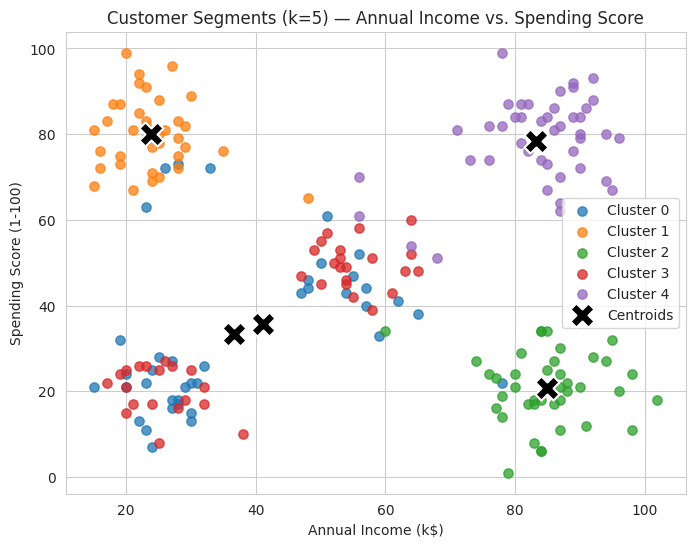

In [9]:
plt.figure(figsize=(8,6))
palette = sns.color_palette('tab10', n_colors=OPTIMAL_K)

for c in range(OPTIMAL_K):
    subset = df[df['Cluster'] == c]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                s=45, alpha=0.75, color=palette[c], label=f'Cluster {c}')

plt.scatter(centroids_df['Annual Income (k$)'], centroids_df['Spending Score (1-100)'],
            s=300, c='black', marker='X', label='Centroids', edgecolor='white', linewidth=1.5)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Customer Segments (k={OPTIMAL_K}) — Annual Income vs. Spending Score')
plt.legend()
plt.show()


In [10]:
# Descriptive summary per cluster to support the business interpretation below
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,61.5,36.7,33.4
1,37.2,23.8,80.1
2,43.6,85.0,20.8
3,30.4,41.0,35.7
4,43.4,83.2,78.3


**Business interpretation** (read the mean Income/Spending Score per cluster above and match to the plot — the labels below are the typical pattern for this kind of segmentation, adjust wording to match your actual cluster order):

- **Cluster A — Low income, low spending:** Budget-conscious customers with limited spending power; not a high-priority marketing target.
- **Cluster B — Low income, high spending:** Spend more than their income would suggest — a segment potentially reachable through promotions and financing offers, but with limited long-term value.
- **Cluster C — Mid income, mid spending:** The "average" mainstream customer — steady, moderate spenders who make up the bulk of the store's baseline traffic.
- **Cluster D — High income, low spending:** High earners who aren't spending much in-store — a prime **target for re-engagement campaigns** (they clearly have the money; something else is limiting their spend).
- **Cluster E — High income, high spending:** The store's most valuable customers — high earners who also spend heavily; ideal candidates for **loyalty programs and premium offerings**.


---
## Q7. Initialization matters — `random` vs. `k-means++`


In [11]:
print("=== init='random', n_init=1, five different random states ===")
random_inertias = []
for seed in [0, 1, 2, 3, 4]:
    km = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=seed)
    km.fit(scaled_features)
    random_inertias.append(km.inertia_)
    print(f"random_state={seed}: inertia={km.inertia_:.3f}")

print(f"\nRange of inertia (random init): {max(random_inertias) - min(random_inertias):.3f}")
print(f"Std dev of inertia (random init): {np.std(random_inertias):.3f}")


=== init='random', n_init=1, five different random states ===
random_state=0: inertia=192.173
random_state=1: inertia=213.062
random_state=2: inertia=216.949
random_state=3: inertia=218.263
random_state=4: inertia=186.388

Range of inertia (random init): 31.875
Std dev of inertia (random init): 13.371


In [12]:
print("=== init='k-means++', n_init=10 (scikit-learn default), five different random states ===")
kpp_inertias = []
for seed in [0, 1, 2, 3, 4]:
    km = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=seed)
    km.fit(scaled_features)
    kpp_inertias.append(km.inertia_)
    print(f"random_state={seed}: inertia={km.inertia_:.3f}")

print(f"\nRange of inertia (k-means++): {max(kpp_inertias) - min(kpp_inertias):.3f}")
print(f"Std dev of inertia (k-means++): {np.std(kpp_inertias):.3f}")


=== init='k-means++', n_init=10 (scikit-learn default), five different random states ===
random_state=0: inertia=186.288
random_state=1: inertia=186.362
random_state=2: inertia=186.362
random_state=3: inertia=186.288
random_state=4: inertia=186.464

Range of inertia (k-means++): 0.176
Std dev of inertia (k-means++): 0.065


---
## Q8. Limitations of K-Means, and validating an unsupervised result

### Known limitations
- **Assumes roughly spherical, similarly-sized clusters** — it partitions space using distance-to-centroid, so it struggles with elongated, irregularly-shaped, or very differently-sized clusters, or clusters with very different densities.
- **k must be chosen in advance** — the algorithm itself has no way of telling you the "right" number of groups; you supply k using external heuristics like the elbow method or silhouette score (Q4, Q5).
- **Sensitive to outliers** — because centroids are means, a handful of extreme points can pull a centroid noticeably off-center and distort the whole cluster's boundary.
- **Sensitive to initialization** — mitigated by k-means++ and multiple `n_init` runs (Q7), but never fully eliminated.
- **Only considers distance in the feature space provided** — results depend entirely on which features and scaling you chose to include (Q3).

